# AG-HYPOPT · Trial 14

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirteen trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803; then trial_05 (0.0822), trial_09 (0.0839), trial_11 (0.0859), trial_06 (0.0861), trial_08 (0.0876), trial_12 (0.0882), trial_13 (0.0888), trial_10 (0.0922). All 0 diverged, gamma finite. trial_07 sits on a narrow interior optimum: sw ~0.85, h_f ~3.9-4.0, h_s ~3.6-3.7, cap ~0.1. Every perturbation so far (cap 0.083/0.146/0.23/0.30, sw 0.50/0.79, h_s 2.13/3.80, sharper h_f) is worse, so the campaign has largely converged. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_14'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (13/5 trials)
ID |     ei | params
 1 | 3.4736 | {"gamma_rel_cap": 0.18991775872134994, "h_f_scale": 3.808817443392376, "h_s_scale": 3.646032166243325, "sigma_weight": 0.8504188829464187}
 2 | 3.8617 | {"gamma_rel_cap": 0.07143035767143519, "h_f_scale": 3.87490279953082, "h_s_scale": 3.6815986843552326, "sigma_weight": 0.8656643626176608}
 3 | 3.9671 | {"gamma_rel_cap": 0.32509709042359436, "h_f_scale": 3.978787930272613, "h_s_scale": 3.6795296371585042, "sigma_weight": 0.846798679374155}
 4 | 2.4981 | {"gamma_rel_cap": 0.22373860028407402, "h_f_scale": 3.517462691315311, "h_s_scale": 0.3605006455784706, "sigma_weight": 0.8466884856959146}
 5 | 3.9933 | {"gamma_rel_cap": 0.22790056198877104, "h_f_scale": 4.0, "h_s_scale": 3.6237018837436947, "sigma_weight": 0.8581693243707728}
 6 | 2.8179 | {"gamma_rel_cap": 0.09198360259213906, "h_f_scale": 3.3207751841395026, "h_s_scale": 3.603359797337535, "sigma_weight": 0.8540937643339251}
 7 | 1.8273 | {"gamma_rel_cap": 0.26145988

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

trial_07 (0.0803) is a narrow interior optimum, and the batch is again almost entirely near-copies of it. Candidate 2 (sw 0.866, h_f 3.875, h_s 3.682) is the closest replica but sets a small cap (0.071) on the side already shown worse (trial_10 0.083); candidate 5 (top ei) sets a larger cap (0.228) also known to be worse; candidate 8 keeps the near-optimal kernels with an intermediate cap (0.167).

Candidate 8 (ei 3.9843) is the most balanced in-region draw: sw 0.849, h_f 4.0, h_s 3.646 - all at the optimum - with a gamma cap 0.167 between trial_07's 0.107 and the worse 0.23-0.30 values, so it tests the upper half of the acceptable cap band without leaving the optimum region.

I choose candidate 8.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8               # candidate 8: sigma_weight 0.849, h_f_scale 4.0, h_s_scale 3.646, gamma_rel_cap 0.167 (in-region, intermediate cap)


chosen: {'gamma_rel_cap': 0.16710972894385737, 'h_f_scale': 4.0, 'h_s_scale': 3.645628986736452, 'sigma_weight': 0.8488354641914216}
Running  1nW Trans05 ... 

μ 9.39 -> 5.93 | γ 8.5 -> 3.97 | NLL 0.25


Running  1nW Trans20 ... 

μ 17.32 -> 27.72 | γ 8.5 -> 5.43 | NLL 0.65


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 62.70 | γ 14.1 -> 13.98 | NLL 0.70


Running 3nW Trans100 ... 

μ 175.71 -> 98.85 | γ 14.1 -> 13.79 | NLL 0.68



Total: 7.8 min


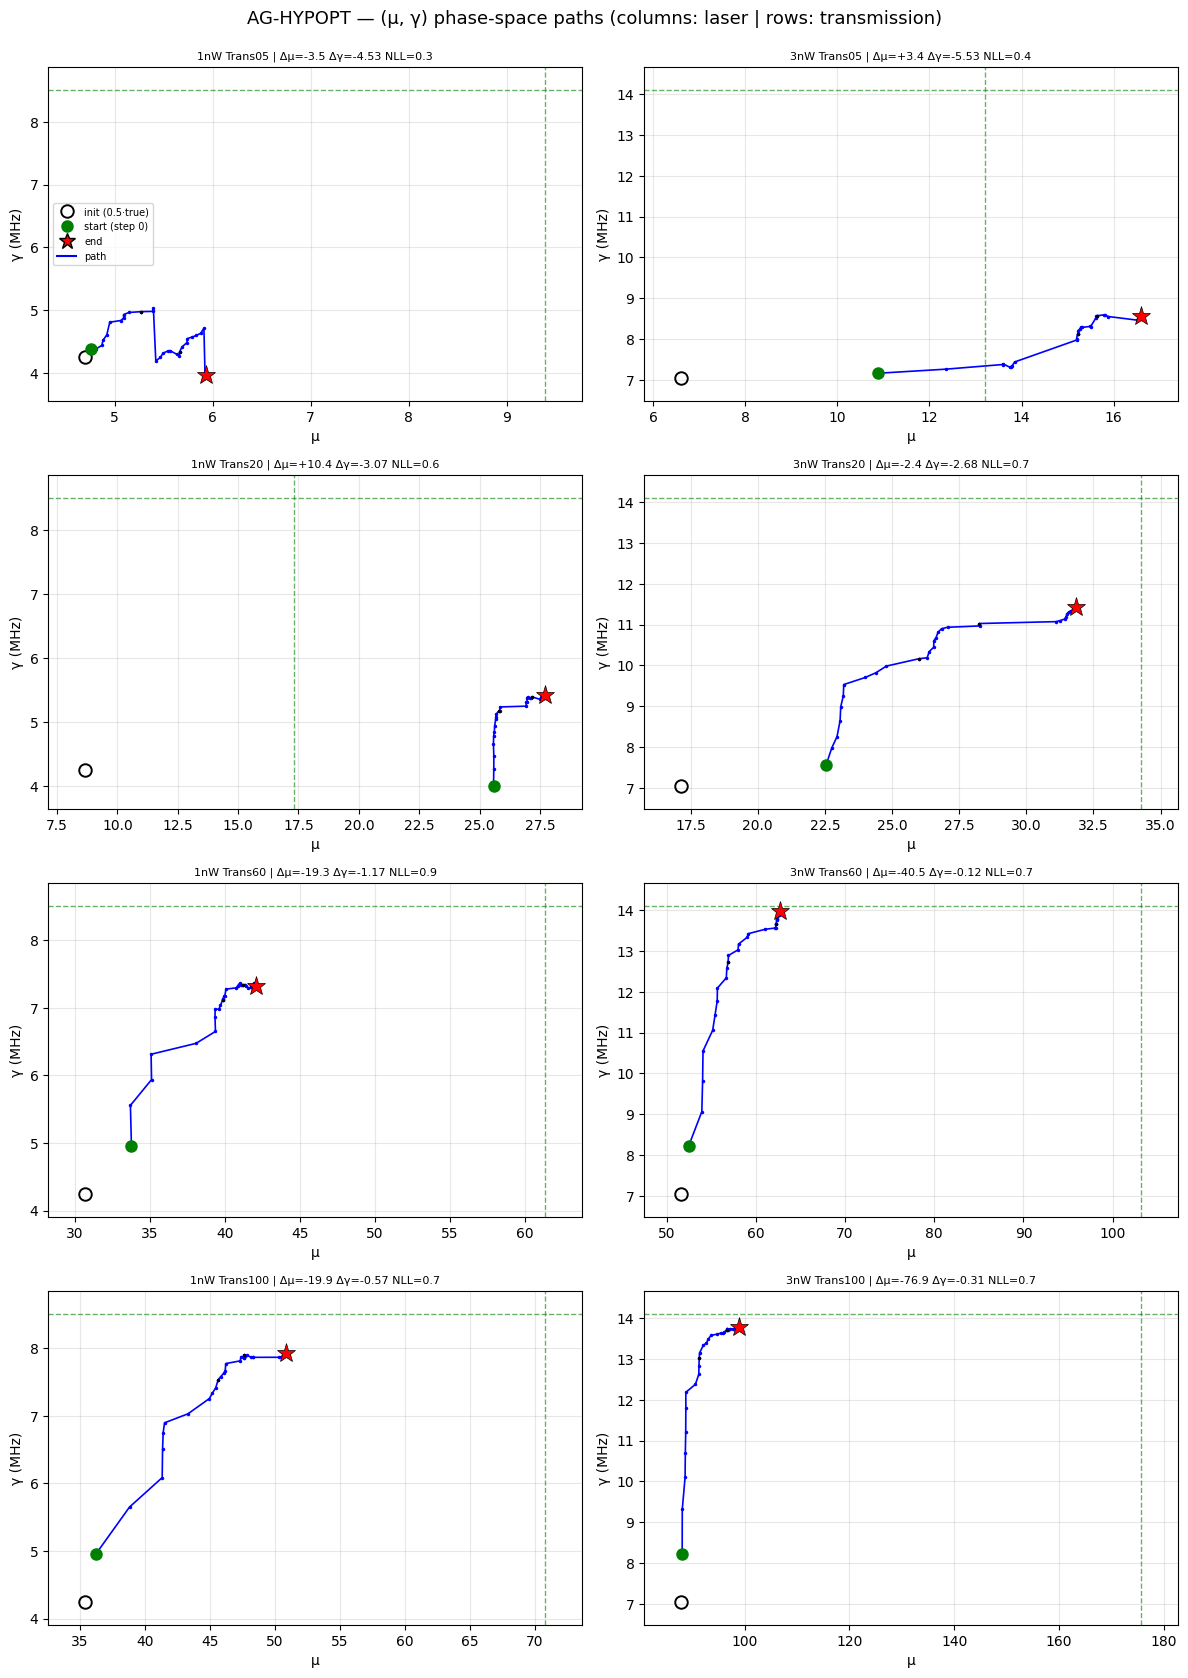

trial finished in 7.8 min
objective = 0.0904 ± 0.0264
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.93   -36.9 |     8.50    3.97   -53.3
1nW Trans20       17.32   27.72   +60.1 |     8.50    5.43   -36.2
1nW Trans60       61.37   42.06   -31.5 |     8.50    7.33   -13.8
1nW Trans100       70.82   50.88   -28.2 |     8.50    7.93    -6.8
3nW Trans05       13.20   16.59   +25.6 |    14.10    8.57   -39.2
3nW Trans20       34.28   31.85    -7.1 |    14.10   11.42   -19.0
3nW Trans60      103.20   62.70   -39.2 |    14.10   13.98    -0.9
3nW Trans100      175.71   98.85   -43.7 |    14.10   13.79    -2.2

weighted objective (T-graded, cap=1.0) = 0.0904 | diverged cells: 0
μ: RMSE 32.511 (rel 36.9%, bias -18.590) | γ: RMSE 2.947 (rel 28.0%, bias -2.249)


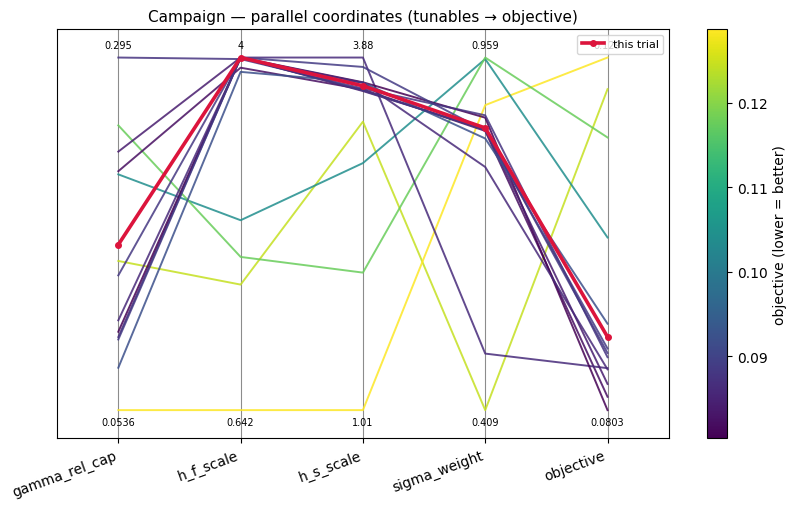

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 14 (sw 0.849, h_f 4.0, h_s 3.646, cap 0.167) ran to completion in 7.8 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0904 +/- 0.0264 - worse than trial_07 (0.0803), near trial_10 (0.0922) at the bottom of the cluster.

mu rel-RMSE 36.9% (slightly worse than trial_07's 35.9%); same shape - high-T undershoot (3nW Trans100 -43.7%, 3nW Trans60 -39.2%, 1nW Trans60 -31.5%, 1nW Trans100 -28.2%), low-T overshoot (1nW Trans20 +60.1%, 3nW Trans05 +25.6%); bias -18.59.

gamma rel-RMSE 28.0% (worse than trial_07's 22.3%): low T under-estimated (1nW Trans05 -53.3%, 3nW Trans05 -39.2%, 1nW Trans20 -36.2%), high T near truth (-0.9%, -2.2%).

The candidate had the exact optimum kernels and a strong sigma weight (0.849), differing from trial_07 only in a larger gamma cap (0.167 vs 0.107); it still did not beat trial_07. The cap optimum is now tightly bracketed on both sides around ~0.1, and the campaign shows no improvement over trial_07 across trials 08-14.

**Summary:** Trial 14 (sw=0.849, h_f=4.0, h_s=3.646, cap=0.167) finished in 7.8 min with 0 diverged cells and gamma finite, objective 0.0904 +/- 0.0264 - worse than trial_07 (mu rel-RMSE 36.9%, gamma rel-RMSE 28.0%).
**Key insight:** An intermediate gamma cap (0.167) also did not beat trial_07, further confirming a tight cap optimum around ~0.1 and no improvement over trial_07 across trials 08-14.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 14 (sw=0.849, h_f=4.0, h_s=3.646, cap=0.167): objective 0.0904 +/- 0.0264 - worse than trial_07; 0 diverged cells, gamma finite (mu rel-RMSE 36.9%, gamma rel-RMSE 28.0%).'
KEY_INSIGHT = 'An intermediate gamma cap (0.167) also did not beat trial_07, further confirming a tight cap optimum around ~0.1 and no improvement over trial_07 across trials 08-14.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_14 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_15.ipynb. Open it and follow its cells from the top.
